In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel

In [ ]:
data = pd.read_csv('weather_classification_data.csv')
data.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [ ]:
data.shape

(13200, 11)

In [ ]:
data.sample(3)

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
4797,5.0,101,38.0,75.0,partly cloudy,981.30,4,Winter,1.0,inland,Snowy
12062,26.0,67,14.0,26.0,partly cloudy,1013.84,4,Winter,5.5,coastal,Cloudy
657,33.0,26,6.5,5.0,clear,1029.26,7,Summer,9.5,coastal,Sunny


In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [ ]:
data.isnull().sum()

,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation (%),0
Cloud Cover,0
Atmospheric Pressure,0
UV Index,0
Season,0
Visibility (km),0
Location,0


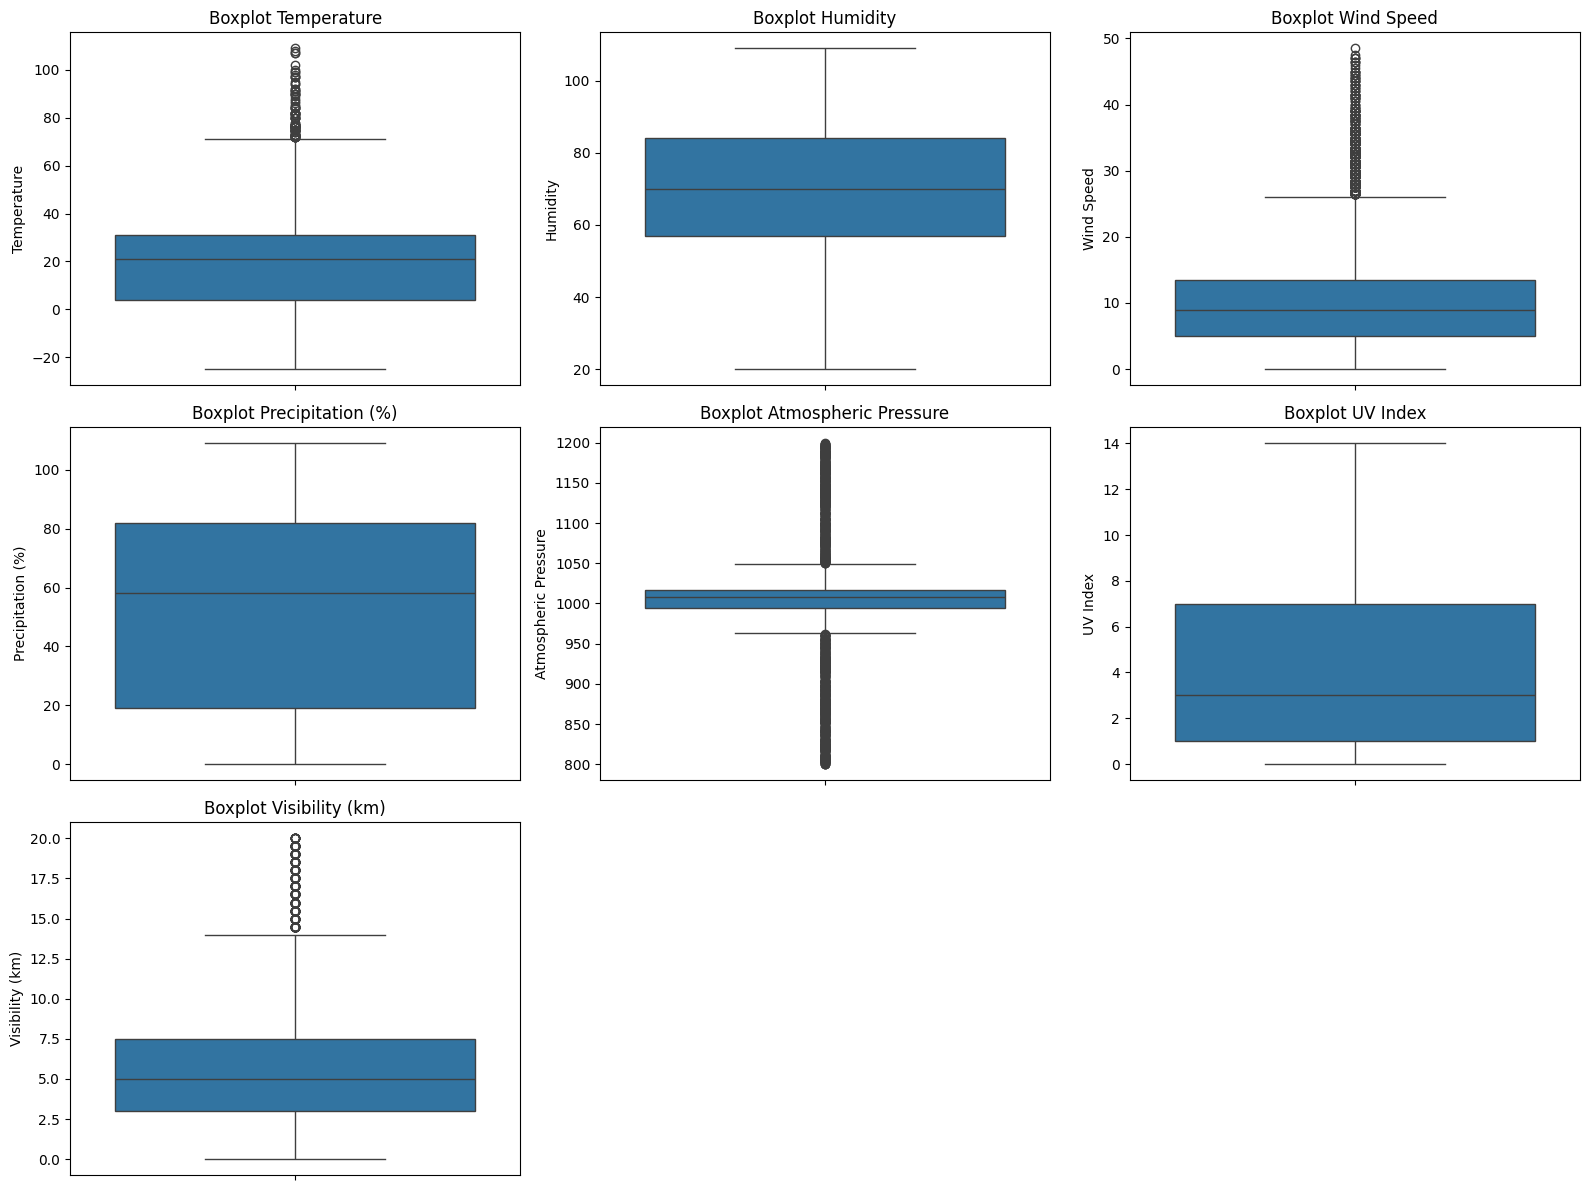

In [ ]:
data.columns = data.columns.str.strip()
numeric_cols = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']

plt.figure(figsize=(16, 12))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot {col}', fontsize=12)
    plt.ylabel(col, fontsize=10)

plt.tight_layout()
plt.savefig('boxplot_weather_features.png')
plt.show()

In [ ]:
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    outliers_removed = 0

    for column in columns:
        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_count = len(df_clean[(df_clean[column] < lower_bound) | (df_clean[column] > upper_bound)])
        outliers_removed += outliers_count
        print(f"Outliers di kolom {column}: {outliers_count} data")

        df_clean = df_clean[(df_clean[column] >= lower_bound) & (df_clean[column] <= upper_bound)]

    print(f"\nTotal outliers yang dihapus: {outliers_removed}")
    print(f"Data tersisa: {len(df_clean)} dari {len(df)} data asli")

    return df_clean

In [ ]:
numeric_columns = data.select_dtypes(include=[np.number]).columns.tolist()
if 'Population_Density' in numeric_columns:
    numeric_columns.remove('Population_Density')

data_clean = remove_outliers_iqr(data, numeric_columns)
data = data_clean.copy()

Outliers di kolom Temperature: 92 data
Outliers di kolom Humidity: 0 data
Outliers di kolom Wind Speed: 396 data
Outliers di kolom Precipitation (%): 0 data
Outliers di kolom Atmospheric Pressure: 927 data
Outliers di kolom UV Index: 112 data
Outliers di kolom Visibility (km): 87 data

Total outliers yang dihapus: 1614
Data tersisa: 11586 dari 13200 data asli


In [ ]:
# Check the column names to see if 'Air Quality' exists
print(data.columns)


Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
       'Visibility (km)', 'Location', 'Weather Type'],
      dtype='object')


In [ ]:
print("\nDistribusi Target Variable (Weather Type):")
weather_type_distribution = data['Weather Type'].value_counts()

print(weather_type_distribution)
print(f"\nJumlah data Keseluruhan: {len(data)}")

for category in weather_type_distribution.index:
    percentage = weather_type_distribution[category] / len(data) * 100
    print(f"Persentase tipe cuaca {category}: {percentage:.2f}%")


Distribusi Target Variable (Weather Type):
Weather Type
Cloudy    2960
Sunny     2941
Snowy     2875
Rainy     2810
Name: count, dtype: int64

Jumlah data Keseluruhan: 11586
Persentase tipe cuaca Cloudy: 25.55%
Persentase tipe cuaca Sunny: 25.38%
Persentase tipe cuaca Snowy: 24.81%
Persentase tipe cuaca Rainy: 24.25%


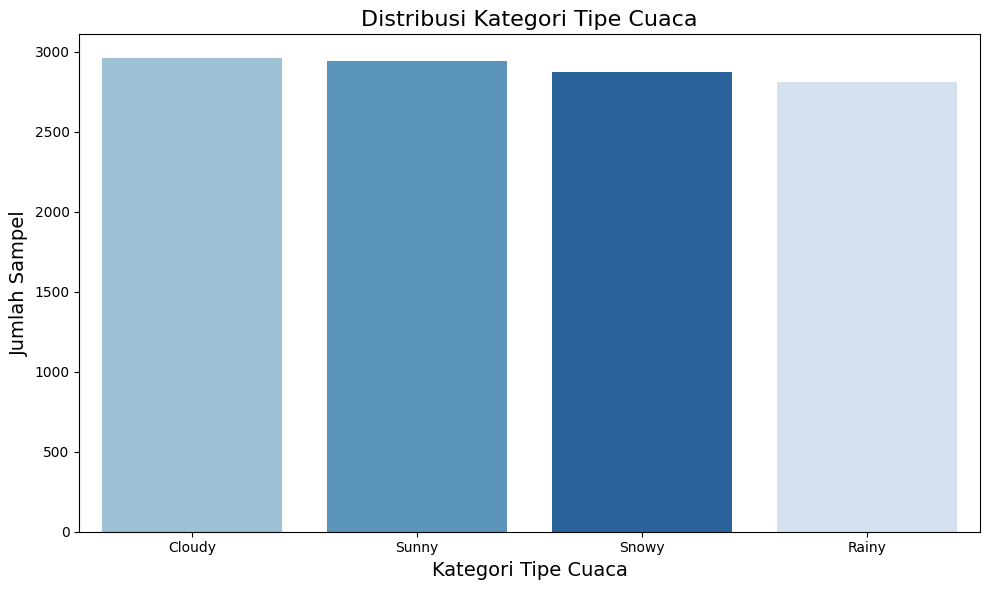

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Weather Type', data=data, hue='Weather Type', palette='Blues', order=data['Weather Type'].value_counts().index)
plt.title('Distribusi Kategori Tipe Cuaca', fontsize=16)
plt.xlabel('Kategori Tipe Cuaca', fontsize=14)
plt.ylabel('Jumlah Sampel', fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('distribusi_tipe_cuaca.png')
plt.show()

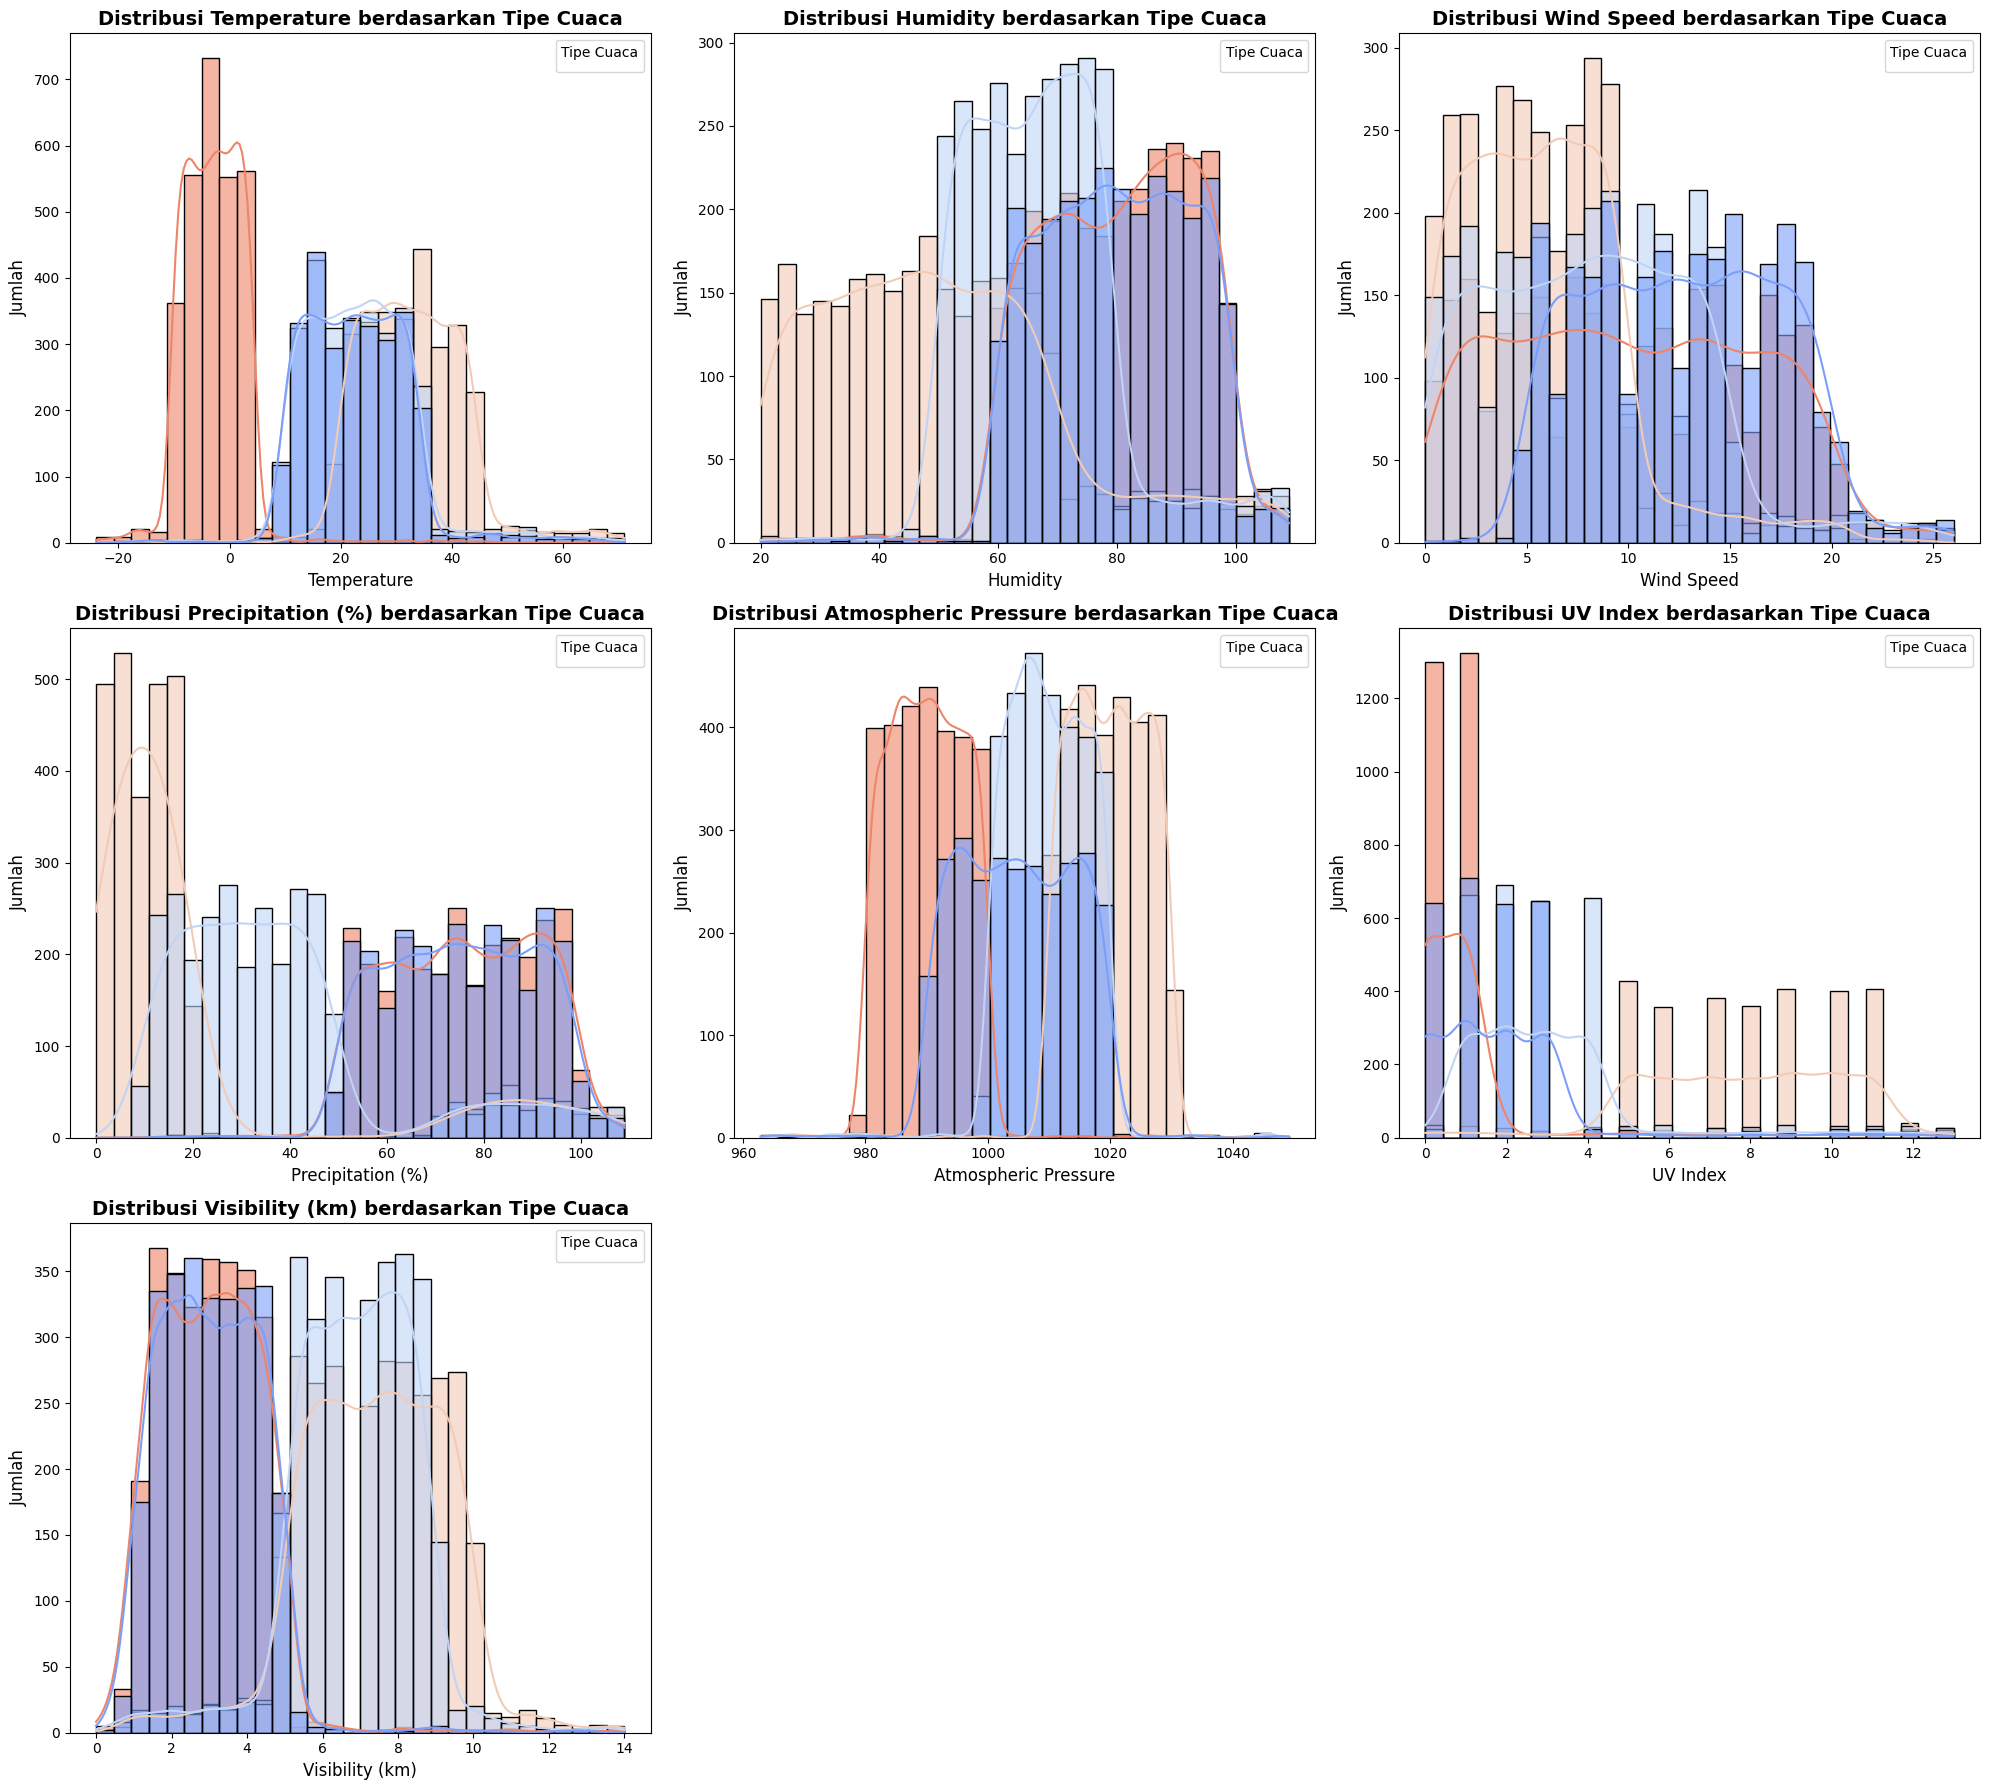

In [ ]:
plt.figure(figsize=(20, 18))
numerical_features = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']

for i, column in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(data=data, x=column, hue='Weather Type', kde=True, palette='coolwarm',
                 bins=30, stat='count', alpha=0.6)
    plt.title(f'Distribusi {column} berdasarkan Tipe Cuaca', fontsize=14, weight='bold')
    plt.xlabel(f'{column}', fontsize=12)
    plt.ylabel('Jumlah', fontsize=12)

    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, labels, title='Tipe Cuaca', fontsize=10)

plt.tight_layout()
plt.savefig('distribusi_variabel_numerik_tipe_cuaca.png', dpi=300)
plt.show()

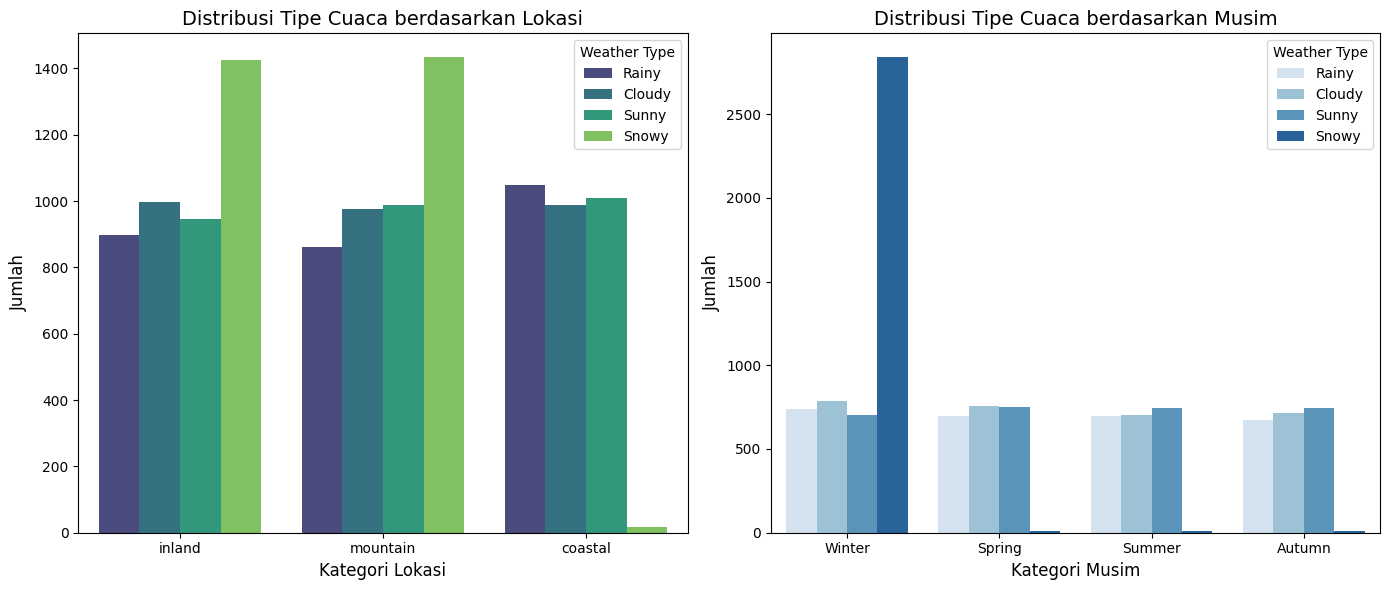

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='Location', hue='Weather Type', data=data, palette='viridis')
plt.title('Distribusi Tipe Cuaca berdasarkan Lokasi', fontsize=14)
plt.xlabel('Kategori Lokasi', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
sns.countplot(x='Season', hue='Weather Type', data=data, palette='Blues')
plt.title('Distribusi Tipe Cuaca berdasarkan Musim', fontsize=14)
plt.xlabel('Kategori Musim', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('distribusi_variabel_kategorik_tipe_cuaca_lokasi_musim.png')
plt.show()

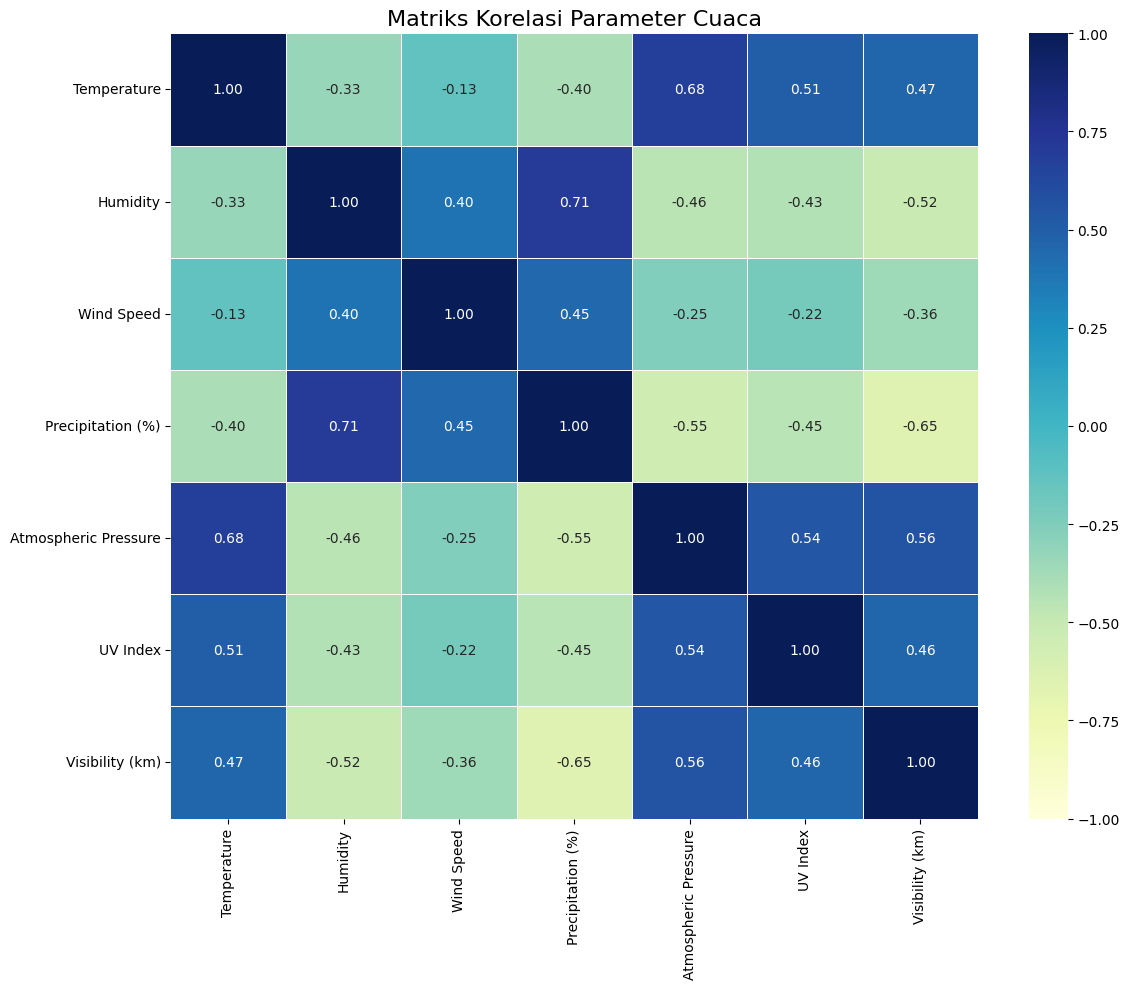

In [ ]:
numeric_data = data.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 10))
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', linewidths=0.5, fmt='.2f', center=0, vmin=-1, vmax=1)
plt.title('Matriks Korelasi Parameter Cuaca', fontsize=16)
plt.tight_layout()
plt.savefig('matriks_korelasi_cuaca.png')
plt.show()

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data['Weather Type'])
X = data.drop(['Weather Type', 'Pop_Density_Category', 'Industrial_Distance_Category'], axis=1, errors='ignore')

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Kolom Pada Data:", numerical_cols)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Kolom Pada Data: ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']


In [ ]:
scaler = StandardScaler()
X_train_num = X_train[numerical_cols]
X_test_num = X_test[numerical_cols]

X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

X_train[numerical_cols] = X_train_scaled
X_test[numerical_cols] = X_test_scaled

In [ ]:
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5), threshold="mean")
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

print(f"Jumlah fitur sebelum seleksi: {X_train_scaled.shape[1]}")
print(f"Jumlah fitur setelah seleksi: {X_train_selected.shape[1]}")
print(f"\nBentuk set pelatihan: {X_train_selected.shape}")
print(f"Bentuk set pengujian: {X_test_selected.shape}")

Jumlah fitur sebelum seleksi: 7
Jumlah fitur setelah seleksi: 4

Bentuk set pelatihan: (9268, 4)
Bentuk set pengujian: (2318, 4)


In [ ]:
print("\nDistribusi kelas pada data training:")
unique, counts = np.unique(y_train, return_counts=True)
for i, (cls, count) in enumerate(zip(label_encoder.classes_, counts)):
    print(f"{cls}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nDistribusi kelas pada data testing:")
unique, counts = np.unique(y_test, return_counts=True)
for i, (cls, count) in enumerate(zip(label_encoder.classes_, counts)):
    print(f"{cls}: {count} ({count/len(y_test)*100:.1f}%)")


Distribusi kelas pada data training:
Cloudy: 2368 (25.6%)
Rainy: 2248 (24.3%)
Snowy: 2300 (24.8%)
Sunny: 2352 (25.4%)

Distribusi kelas pada data testing:
Cloudy: 592 (25.5%)
Rainy: 562 (24.2%)
Snowy: 575 (24.8%)
Sunny: 589 (25.4%)


In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

print("\nDistribusi sebelum SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(label_encoder.classes_, counts):
    print(f"{cls}: {count}")

print("\nDistribusi setelah SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for cls, count in zip(label_encoder.classes_, counts):
    print(f"{cls}: {count}")


Distribusi sebelum SMOTE:
Cloudy: 2368
Rainy: 2248
Snowy: 2300
Sunny: 2352

Distribusi setelah SMOTE:
Cloudy: 2368
Rainy: 2368
Snowy: 2368
Sunny: 2368


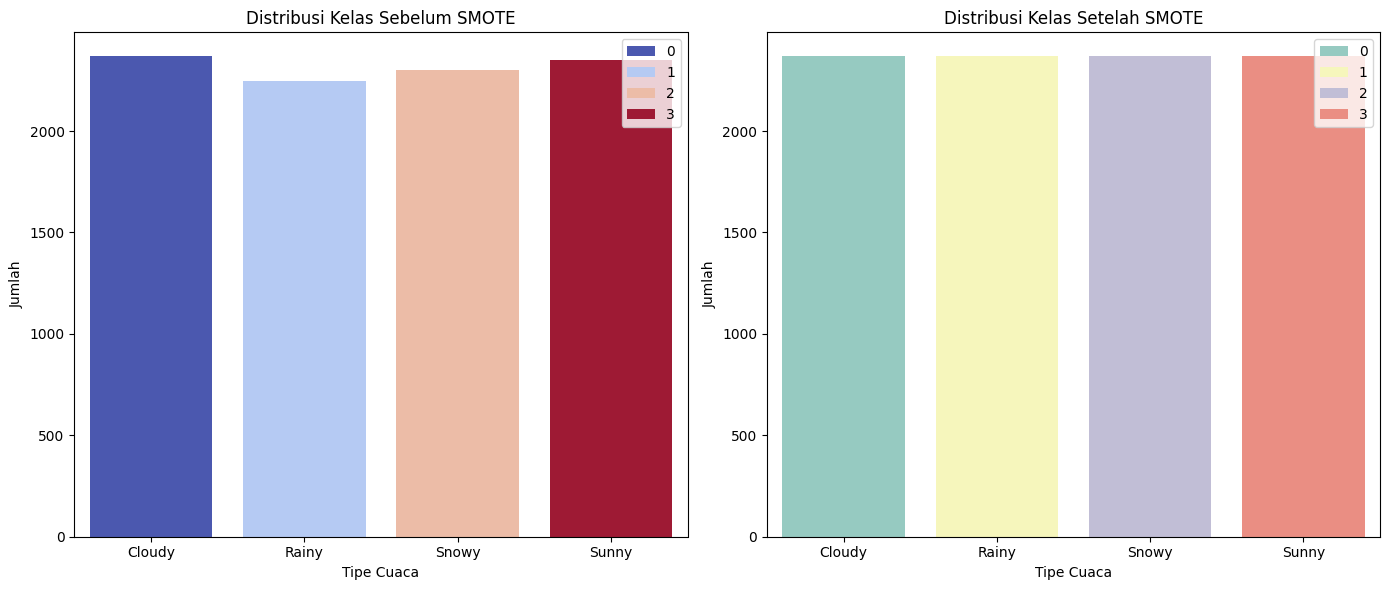

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, hue=y_train, palette='coolwarm')
plt.title("Distribusi Kelas Sebelum SMOTE")
plt.xlabel("Tipe Cuaca")
plt.ylabel("Jumlah")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=0)

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote, hue=y_train_smote, palette='Set3')
plt.title("Distribusi Kelas Setelah SMOTE")
plt.xlabel("Tipe Cuaca")
plt.ylabel("Jumlah")
plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=0)

plt.tight_layout()
plt.savefig("distribusi_setelah_smote_tipe_cuaca.png")
plt.show()

In [ ]:
def plot_matriks_konfusi(y_true, y_pred, title="Model"):
    labels = sorted(list(set(y_true)))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='cividis', cbar=True,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)

    plt.xlabel("Label Prediksi")
    plt.ylabel("Label Sebenarnya")
    plt.title(f"Matriks Konfusi - {title}")
    plt.tight_layout()
    plt.show()

In [ ]:
param_grid_knn = {
    'n_neighbors': [7, 11],  # Number of neighbors to test
    'weights': ['uniform', 'distance'],  # Weight function for prediction
    'algorithm': ['auto', 'ball_tree', 'kd_tree']  # Algorithm to compute nearest neighbors
}

# Initialize GridSearchCV with KNeighborsClassifier
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='f1_weighted', n_jobs=-1)

# Fit GridSearchCV to the SMOTE-resampled training data
grid_knn.fit(X_train_smote, y_train_smote)



# Get the best model after GridSearchCV
knn_model_best = grid_knn.best_estimator_

# Train the best KNN model on the SMOTE-resampled training data
knn_model_best.fit(X_train_smote, y_train_smote)

KNeighborsClassifier(n_neighbors=7, weights='distance')

In [ ]:
# Predict using the trained KNN model on the SMOTE-resampled training data
knn_train_pred = knn_model_best.predict(X_train_smote)

# Calculate evaluation metrics on the training data
knn_train_accuracy = accuracy_score(y_train_smote, knn_train_pred)
knn_train_precision = precision_score(y_train_smote, knn_train_pred, average='weighted')
knn_train_recall = recall_score(y_train_smote, knn_train_pred, average='weighted')
knn_train_f1 = f1_score(y_train_smote, knn_train_pred, average='weighted')

# Print evaluation metrics for the KNN on the training data
print("Metrik Evaluasi KNN pada Data Training")
print(f"Akurasi: {knn_train_accuracy:.4f}")
print(f"Presisi: {knn_train_precision:.4f}")
print(f"Recall: {knn_train_recall:.4f}")
print(f"F1-Score: {knn_train_f1:.4f}")


Metrik Evaluasi KNN pada Data Training
Akurasi: 0.9999
Presisi: 0.9999
Recall: 0.9999
F1-Score: 0.9999


In [ ]:
# Predict using the trained KNN model on the test data
knn_test_pred = knn_model_best.predict(X_test_selected)

# Calculate evaluation metrics on the test data
knn_test_accuracy = accuracy_score(y_test, knn_test_pred)
knn_test_precision = precision_score(y_test, knn_test_pred, average='weighted')
knn_test_recall = recall_score(y_test, knn_test_pred, average='weighted')
knn_test_f1 = f1_score(y_test, knn_test_pred, average='weighted')

# Print evaluation metrics for the KNN on the test data
print("Metrik Evaluasi KNN pada Data Testing")
print(f"Akurasi: {knn_test_accuracy:.4f}")
print(f"Presisi: {knn_test_precision:.4f}")
print(f"Recall: {knn_test_recall:.4f}")
print(f"F1-Score: {knn_test_f1:.4f}")

# Print the classification report for the test data
print("\nLaporan Klasifikasi KNN:")
print(classification_report(y_test, knn_test_pred, target_names=label_encoder.classes_))


Metrik Evaluasi KNN pada Data Testing
Akurasi: 0.9400
Presisi: 0.9401
Recall: 0.9400
F1-Score: 0.9400

Laporan Klasifikasi KNN:
              precision    recall  f1-score   support

      Cloudy       0.92      0.93      0.92       592
       Rainy       0.94      0.95      0.95       562
       Snowy       0.98      0.97      0.98       575
       Sunny       0.92      0.91      0.92       589

    accuracy                           0.94      2318
   macro avg       0.94      0.94      0.94      2318
weighted avg       0.94      0.94      0.94      2318

